## Giai đoạn 4: Đánh giá và diễn giải mô hình

- Tính đầy đủ các metrics: Accuracy, Precision, Recall, F1-weighted, ROC-AUC
- Vẽ ROC Curve (multi-class One-vs-Rest)
- Phân tích SHAP values — giải thích tại sao model ra quyết định đó
- Lưu tất cả biểu đồ vào `reports/figures/`

> **Lưu ý:** Notebook này đọc trực tiếp model và dữ liệu từ notebook 03. Cần chạy notebook 03 trước.

In [ ]:
pip install shap

### Task 1: Tải thư viện và nạp model từ notebook 03

In [3]:
import warnings
warnings.filterwarnings('ignore')

import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap
import joblib

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

PROCESSED_DIR = '../data/processed'
MODELS_DIR    = '../models'
FIGURES_DIR   = '../reports/figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

BURNOUT_LABEL = {
    1: 'Không có dấu hiệu',
    2: 'Ít dấu hiệu',
    3: 'Cần chú ý',
    4: 'Nguy cơ cao',
    5: 'Nguy cơ rất cao',
}
BURNOUT_COLOR = {
    1: '#4CAF50', 2: '#8BC34A', 3: '#FFC107', 4: '#FF5722', 5: '#C62828'
}

# Nạp model & config từ notebook 03
rf_model = joblib.load(f'{MODELS_DIR}/rf_model.pkl')
selector = joblib.load(f'{MODELS_DIR}/variance_selector.pkl')

with open(f'{MODELS_DIR}/rf_config.json', encoding='utf-8') as f:
    config = json.load(f)

kept_cols = config['kept_features']

# Nạp dữ liệu test
X_test_raw = pd.read_csv(f'{PROCESSED_DIR}/X_test.csv')
y_test     = pd.read_csv(f'{PROCESSED_DIR}/y_test.csv').squeeze()
X_train    = pd.read_csv(f'{PROCESSED_DIR}/X_train.csv')
y_train    = pd.read_csv(f'{PROCESSED_DIR}/y_train.csv').squeeze()

# Áp dụng feature selection (dùng selector đã fit từ notebook 03)
X_test  = pd.DataFrame(selector.transform(X_test_raw),  columns=kept_cols)
X_train_sel = pd.DataFrame(selector.transform(X_train), columns=kept_cols)

# Dự đoán
y_pred      = rf_model.predict(X_test)
y_prob      = rf_model.predict_proba(X_test)
classes     = sorted(rf_model.classes_)
class_names = [BURNOUT_LABEL.get(c, str(c)) for c in classes]

print('✅ Nạp model & dữ liệu thành công!')
print(f'   Model version  : {config["version"]}')
print(f'   Features dùng  : {len(kept_cols)}')
print(f'   Test set       : {len(y_test):,} mẫu')
print(f'   Các lớp        : {classes} → {class_names}')

✅ Nạp model & dữ liệu thành công!
   Model version  : v2_smote_featsel
   Features dùng  : 68
   Test set       : 287 mẫu
   Các lớp        : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)] → ['Không có dấu hiệu', 'Ít dấu hiệu', 'Cần chú ý', 'Nguy cơ cao', 'Nguy cơ rất cao']


### Task 2: Bảng tổng hợp tất cả Metrics

- Tính đầy đủ 5 metrics chính để đưa vào **bảng kết quả trong báo cáo khóa luận**.

📊 BẢNG TỔNG HỢP METRICS — Best Random Forest Model



,Metric,Giá trị,Mô tả
0,Accuracy,0.3798,Tỷ lệ dự đoán đúng tổng thể
1,Precision (weighted),0.3799,"Độ chính xác, tính trọng số theo số mẫu mỗi lớp"
2,Recall (weighted),0.3798,"Độ nhạy, tính trọng số theo số mẫu mỗi lớp"
3,F1-score (weighted),0.3744,Trung bình điều hòa Precision & Recall (có trọ...
4,F1-score (macro),0.2325,Trung bình F1 của từng lớp (không có trọng số)
5,ROC-AUC (macro OvR),0.5905,"Diện tích dưới đường ROC, chiến lược One-vs-Rest"


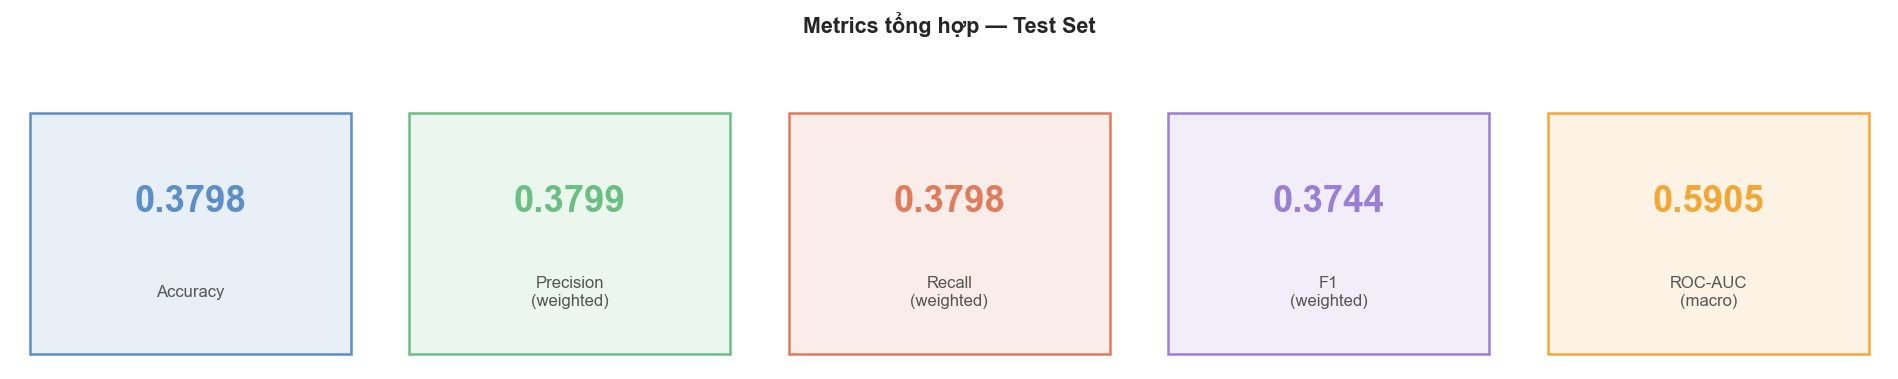

In [8]:
acc   = accuracy_score(y_test, y_pred)
prec  = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec   = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1_w  = f1_score(y_test, y_pred, average='weighted', zero_division=0)
f1_m  = f1_score(y_test, y_pred, average='macro', zero_division=0)

# ROC-AUC macro (One-vs-Rest)
y_test_bin = label_binarize(y_test, classes=classes)
if y_test_bin.shape[1] == 1:
    roc_auc_macro = auc(*roc_curve(y_test_bin.ravel(), y_prob[:, 1])[:2])
else:
    aucs = []
    for i in range(len(classes)):
        if y_test_bin[:, i].sum() > 0:
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
            aucs.append(auc(fpr, tpr))
    roc_auc_macro = np.mean(aucs)

# Bảng metrics tổng hợp
metrics_summary = pd.DataFrame({
    'Metric'     : ['Accuracy', 'Precision (weighted)', 'Recall (weighted)',
                    'F1-score (weighted)', 'F1-score (macro)', 'ROC-AUC (macro OvR)'],
    'Giá trị'    : [acc, prec, rec, f1_w, f1_m, roc_auc_macro],
    'Mô tả'      : [
        'Tỷ lệ dự đoán đúng tổng thể',
        'Độ chính xác, tính trọng số theo số mẫu mỗi lớp',
        'Độ nhạy, tính trọng số theo số mẫu mỗi lớp',
        'Trung bình điều hòa Precision & Recall (có trọng số)',
        'Trung bình F1 của từng lớp (không có trọng số)',
        'Diện tích dưới đường ROC, chiến lược One-vs-Rest',
    ]
})
metrics_summary['Giá trị'] = metrics_summary['Giá trị'].round(4)

print('📊 BẢNG TỔNG HỢP METRICS — Best Random Forest Model\n')
display(metrics_summary)

# Dashboard metrics dạng card
fig, axes = plt.subplots(1, 5, figsize=(16, 3))
metric_data = [
    ('Accuracy',    acc,          '#5C8EC7'),
    ('Precision\n(weighted)', prec, '#6BBF83'),
    ('Recall\n(weighted)',    rec,  '#E07B5C'),
    ('F1\n(weighted)',        f1_w, '#9B7FD4'),
    ('ROC-AUC\n(macro)',  roc_auc_macro, '#F4A636'),
]
for ax, (name, val, color) in zip(axes, metric_data):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.add_patch(plt.Rectangle((0.05, 0.05), 0.9, 0.9,
                                facecolor=color + '22', edgecolor=color,
                                linewidth=1.5, transform=ax.transAxes))
    ax.text(0.5, 0.62, f'{val:.4f}', ha='center', va='center',
            fontsize=22, fontweight='bold', color=color, transform=ax.transAxes)
    ax.text(0.5, 0.28, name, ha='center', va='center',
            fontsize=10, color='#555555', transform=ax.transAxes)

plt.suptitle('Metrics tổng hợp — Test Set', fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/20_metrics_dashboard.png', bbox_inches='tight')
plt.show()

### Task 3: ROC Curve (Multi-class One-vs-Rest)

- Mỗi lớp Burn Out được vẽ một đường ROC riêng. Đường nào có **AUC càng gần 1** thì model phân biệt lớp đó càng tốt.

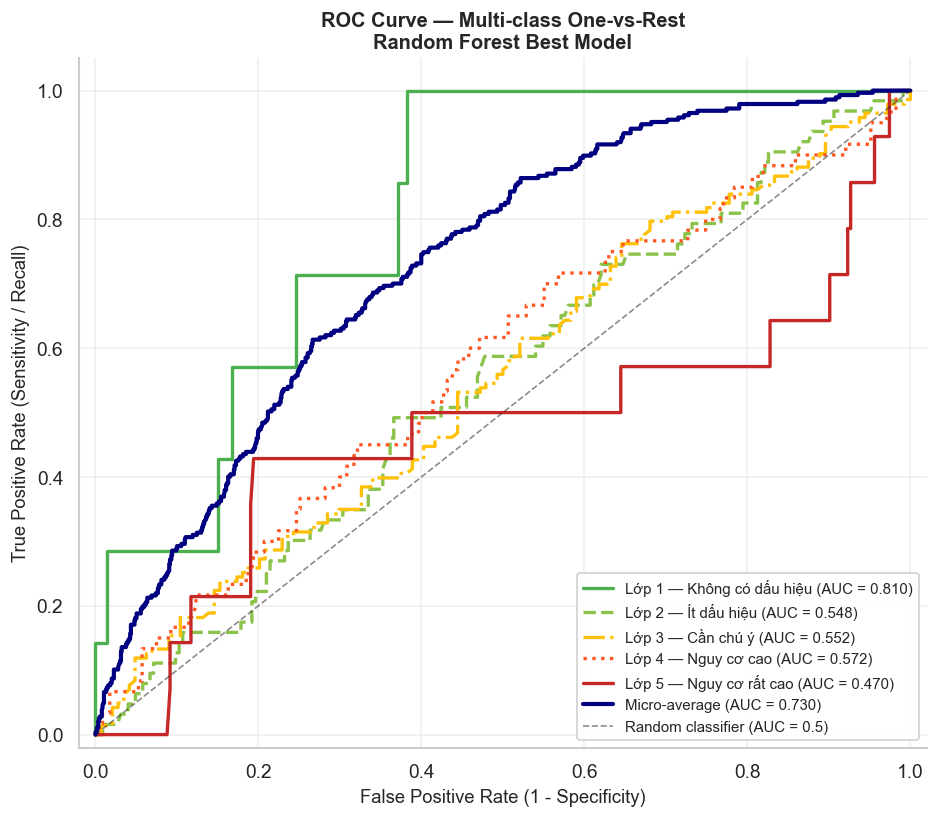


📊 AUC theo từng lớp:
   Lớp 1 — Không có dấu hiệu     : AUC = 0.8097  ████████████████
   Lớp 2 — Ít dấu hiệu           : AUC = 0.5477  ██████████
   Lớp 3 — Cần chú ý             : AUC = 0.5522  ███████████
   Lớp 4 — Nguy cơ cao           : AUC = 0.5723  ███████████
   Lớp 5 — Nguy cơ rất cao       : AUC = 0.4704  █████████
   Micro-average              : AUC = 0.7301
   Macro-average              : AUC = 0.5905


In [9]:
y_test_bin = label_binarize(y_test, classes=classes)
n_classes  = len(classes)

fpr_dict  = {}
tpr_dict  = {}
auc_dict  = {}

for i, cls in enumerate(classes):
    if n_classes == 2:
        fpr, tpr, _ = roc_curve(y_test_bin[:, 0], y_prob[:, 1])
    else:
        if y_test_bin[:, i].sum() == 0:
            continue
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    fpr_dict[cls]  = fpr
    tpr_dict[cls]  = tpr
    auc_dict[cls]  = auc(fpr, tpr)

# Micro-average ROC
if n_classes > 2 and y_test_bin.shape[1] > 1:
    fpr_micro, tpr_micro, _ = roc_curve(
        y_test_bin.ravel(), y_prob.ravel()
    )
    auc_micro = auc(fpr_micro, tpr_micro)
else:
    fpr_micro, tpr_micro, auc_micro = None, None, None

# Vẽ ROC
fig, ax = plt.subplots(figsize=(8, 7))

line_styles = ['-', '--', '-.', ':', '-']
for i, cls in enumerate(fpr_dict):
    color = BURNOUT_COLOR.get(cls, '#888')
    label = f'Lớp {cls} — {BURNOUT_LABEL.get(cls, str(cls))} (AUC = {auc_dict[cls]:.3f})'
    ax.plot(fpr_dict[cls], tpr_dict[cls],
            color=color, linewidth=2,
            linestyle=line_styles[i % len(line_styles)],
            label=label)

if auc_micro is not None:
    ax.plot(fpr_micro, tpr_micro,
            color='navy', linewidth=2.5, linestyle='-',
            label=f'Micro-average (AUC = {auc_micro:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random classifier (AUC = 0.5)')
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.05])
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
ax.set_ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=11)
ax.set_title('ROC Curve — Multi-class One-vs-Rest\nRandom Forest Best Model',
             fontweight='bold', fontsize=12)
ax.legend(loc='lower right', fontsize=9, framealpha=0.9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/21_roc_curve.png', bbox_inches='tight')
plt.show()

print('\n📊 AUC theo từng lớp:')
for cls, auc_val in auc_dict.items():
    bar = '█' * int(auc_val * 20)
    print(f'   Lớp {cls} — {BURNOUT_LABEL.get(cls,str(cls)):22s}: AUC = {auc_val:.4f}  {bar}')
if auc_micro:
    print(f'   Micro-average              : AUC = {auc_micro:.4f}')
print(f'   Macro-average              : AUC = {roc_auc_macro:.4f}')

### Task 4:  SHAP: Khởi tạo Explainer

- **SHAP (SHapley Additive exPlanations)** giải thích tại sao model đưa ra một dự đoán cụ thể. Không như Feature Importance chỉ cho biết feature nào quan trọng toàn cục, SHAP cho biết feature đó **tác động theo hướng nào** (tăng hay giảm xác suất burnout) và **với mức độ bao nhiêu**.

> ⏱ Bước này tính toán SHAP values cho toàn bộ test set — mất 1–3 phút.

In [10]:
print('🔄 Khởi tạo SHAP TreeExplainer...')

# TreeExplainer được tối ưu riêng cho Random Forest — nhanh hơn KernelExplainer nhiều lần
explainer = shap.TreeExplainer(rf_model)

print('🔄 Tính SHAP values cho test set...')
shap_values = explainer.shap_values(X_test)

# shap_values là list: mỗi phần tử = matrix cho 1 lớp
# shape của mỗi phần tử: (n_samples, n_features)
print(f'\n✅ SHAP values đã tính xong!')
print(f'   Số lớp             : {len(shap_values)}')
print(f'   Shape mỗi lớp      : {shap_values[0].shape}')
print(f'   Features           : {X_test.shape[1]}')
print(f'   Samples (test set) : {X_test.shape[0]}')
print(f'\n   Ý nghĩa: SHAP value dương → feature làm TĂNG xác suất dự đoán lớp đó')
print(f'            SHAP value âm   → feature làm GIẢM xác suất dự đoán lớp đó')

🔄 Khởi tạo SHAP TreeExplainer...
🔄 Tính SHAP values cho test set...

✅ SHAP values đã tính xong!
   Số lớp             : 287
   Shape mỗi lớp      : (68, 5)
   Features           : 68
   Samples (test set) : 287

   Ý nghĩa: SHAP value dương → feature làm TĂNG xác suất dự đoán lớp đó
            SHAP value âm   → feature làm GIẢM xác suất dự đoán lớp đó


### Task 5: SHAP Summary Plot: Tầm quan trọng toàn cục

**Summary Plot** kết hợp Feature Importance + hướng tác động:
- Trục ngang = SHAP value (tác động lên xác suất dự đoán)
- Màu điểm = giá trị feature (đỏ = cao, xanh = thấp)
- Feature ở trên cùng = quan trọng nhất

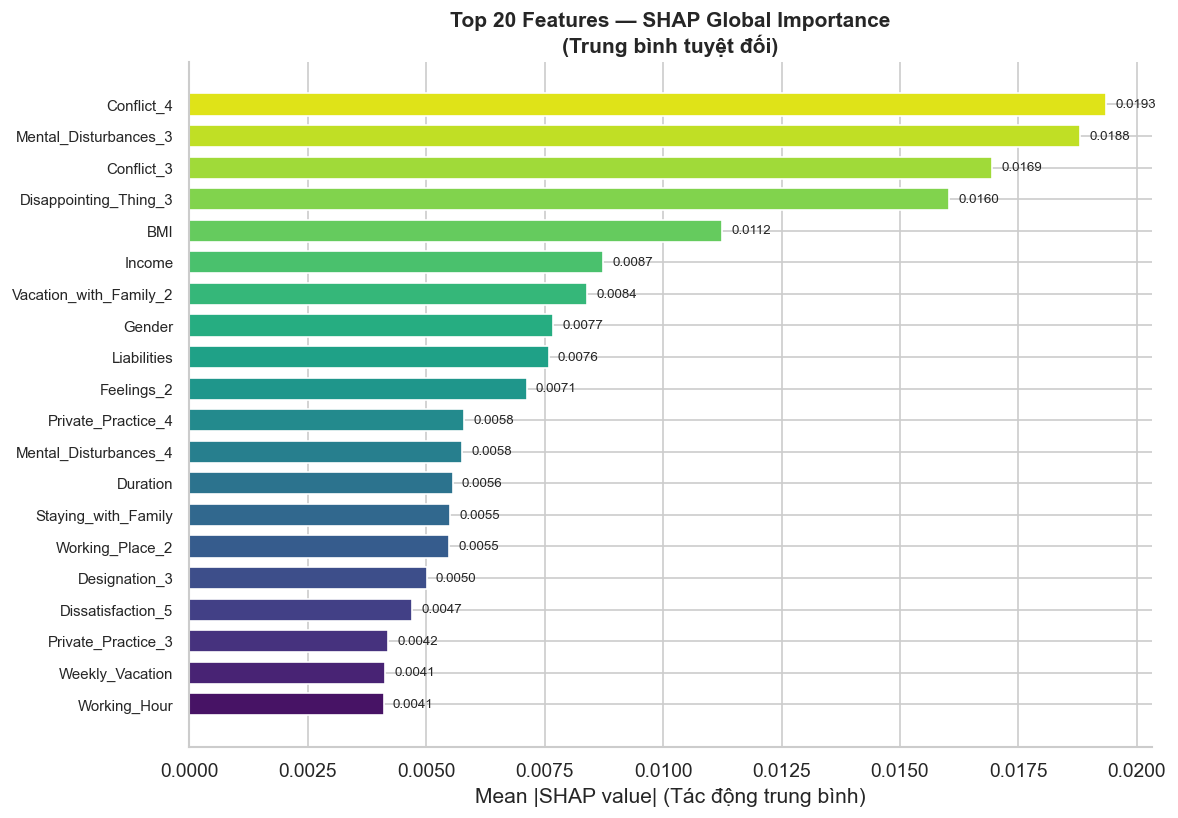

📊 Top 10 features theo SHAP global importance:
    1. Conflict_4                            : 0.01935
    2. Mental_Disturbances_3                 : 0.01880
    3. Conflict_3                            : 0.01694
    4. Disappointing_Thing_3                 : 0.01604
    5. BMI                                   : 0.01125
    6. Income                                : 0.00873
    7. Vacation_with_Family_2                : 0.00840
    8. Gender                                : 0.00769
    9. Liabilities                           : 0.00759
   10. Feelings_2                            : 0.00712


In [13]:
# Giả sử shap_values và kept_cols đã được định nghĩa trước đó
# Kiểm tra cấu trúc của shap_values để tính toán giá trị trung bình tuyệt đối
if isinstance(shap_values, list):
    # Trường hợp shap_values là danh sách các mảng (thường gặp trong Multi-class)
    mean_abs_shap = np.mean([np.abs(sv) for sv in shap_values], axis=0)
    mean_feature_shap = mean_abs_shap.mean(axis=0)
elif len(shap_values.shape) == 3:
    # shap_values là mảng 3D: (samples, features, classes)
    mean_feature_shap = np.abs(shap_values).mean(axis=(0, 2))
else:
    # shap_values là mảng 2D thông thường: (samples, features)
    mean_feature_shap = np.abs(shap_values).mean(axis=0)

# Tạo Series để sắp xếp
shap_mean_series = pd.Series(
    mean_feature_shap, 
    index=kept_cols
).sort_values(ascending=False)

# --- Plotting ---
top_n = min(20, len(shap_mean_series))
top_feats = shap_mean_series.head(top_n)

fig, ax = plt.subplots(figsize=(10, 7))
# Tạo palette màu sinh động hơn
palette = sns.color_palette('viridis', top_n)

# Vẽ biểu đồ thanh ngang
bars = ax.barh(range(top_n), top_feats.values[::-1], 
               color=palette, edgecolor='white', height=0.7)

# Thiết lập trục y và nhãn
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_feats.index[::-1], fontsize=9)

# Thêm giá trị số vào đầu mỗi thanh
for i, val in enumerate(top_feats.values[::-1]):
    ax.text(val + (top_feats.max() * 0.01), i, f'{val:.4f}', va='center', fontsize=8)

ax.set_xlabel('Mean |SHAP value| (Tác động trung bình)')
ax.set_title(f'Top {top_n} Features — SHAP Global Importance\n(Trung bình tuyệt đối)', 
             fontweight='bold')

plt.tight_layout()
# plt.savefig(f'{FIGURES_DIR}/22_shap_global_importance.png', bbox_inches='tight')
plt.show()

print('📊 Top 10 features theo SHAP global importance:')
for i, (feat, val) in enumerate(shap_mean_series.head(10).items(), 1):
    print(f'   {i:2d}. {feat:<38}: {val:.5f}')

### Task 6: SHAP Summary Plot theo từng lớp

- Xem feature nào đẩy model về phía **từng lớp burnout** cụ thể. Đặc biệt hữu ích để hiểu: yếu tố nào phân biệt "Nguy cơ cao" vs "Cần chú ý".

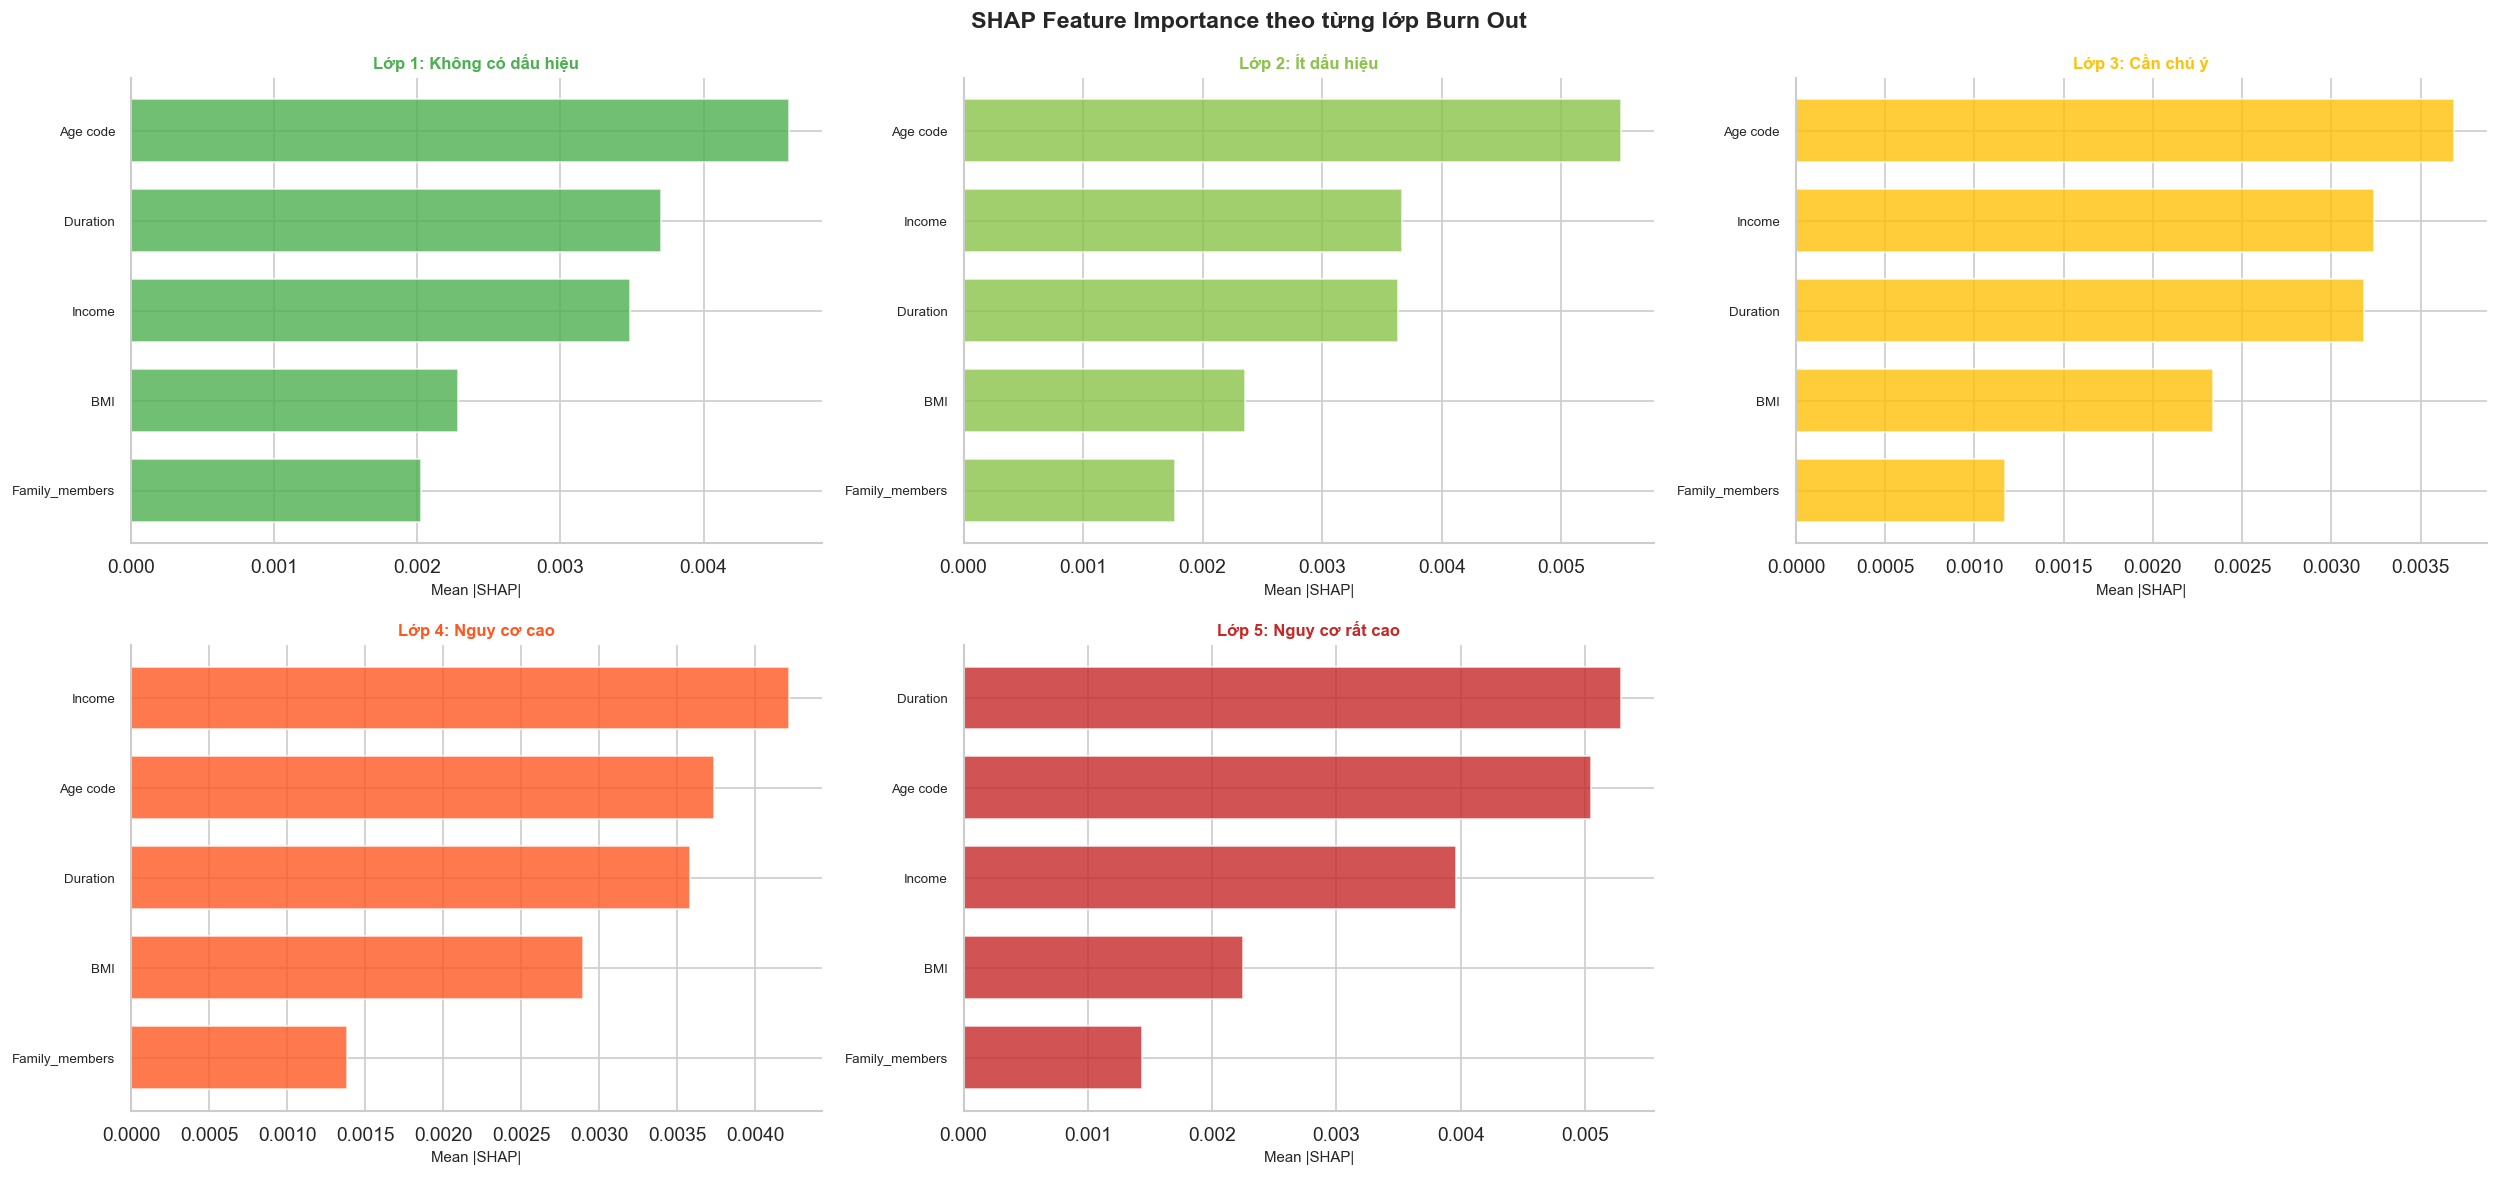

In [15]:
n_cls   = len(classes)
n_cols  = min(3, n_cls)
n_rows  = int(np.ceil(n_cls / n_cols))
top_k   = min(15, len(kept_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 5 * n_rows))
axes_flat = np.array(axes).flatten() if n_cls > 1 else [axes]

for i, (cls, ax) in enumerate(zip(classes, axes_flat)):
    sv    = shap_values[i]                          # (n_samples, n_features)
    means = np.abs(sv).mean(axis=0)

    # Tính toán lại số lượng feature thực tế có thể lấy
    current_k = min(top_k, len(means))

    top_idx = np.argsort(means)[::-1][:current_k]
    top_names = [kept_cols[j] for j in top_idx]
    top_vals = means[top_idx]

    color = BURNOUT_COLOR.get(cls, '#888')

    # Sử dụng current_k thay vì top_k cố định
    y_pos = np.arange(current_k) 
    
    ax.barh(y_pos, top_vals[::-1],
            color=color, alpha=0.8, edgecolor='white', height=0.7)
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(top_names[::-1], fontsize=8)
    
    ax.set_title(f'Lớp {cls}: {BURNOUT_LABEL.get(cls, str(cls))}',
                 fontweight='bold', fontsize=10, color=color)
    ax.set_xlabel('Mean |SHAP|', fontsize=9)

for j in range(n_cls, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle('SHAP Feature Importance theo từng lớp Burn Out',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/23_shap_per_class.png', bbox_inches='tight')
plt.show()

### Task 7: SHAP Beeswarm Plot

**Beeswarm (Dot) Plot** cho thấy cả tầm quan trọng lẫn **hướng tác động** cùng một lúc:
- Mỗi chấm = một mẫu trong test set
- Màu đỏ = giá trị feature cao, màu xanh = giá trị feature thấp
- Chấm bên phải trục 0 → tăng xác suất dự đoán lớp đó
- Chấm bên trái trục 0 → giảm xác suất dự đoán lớp đó

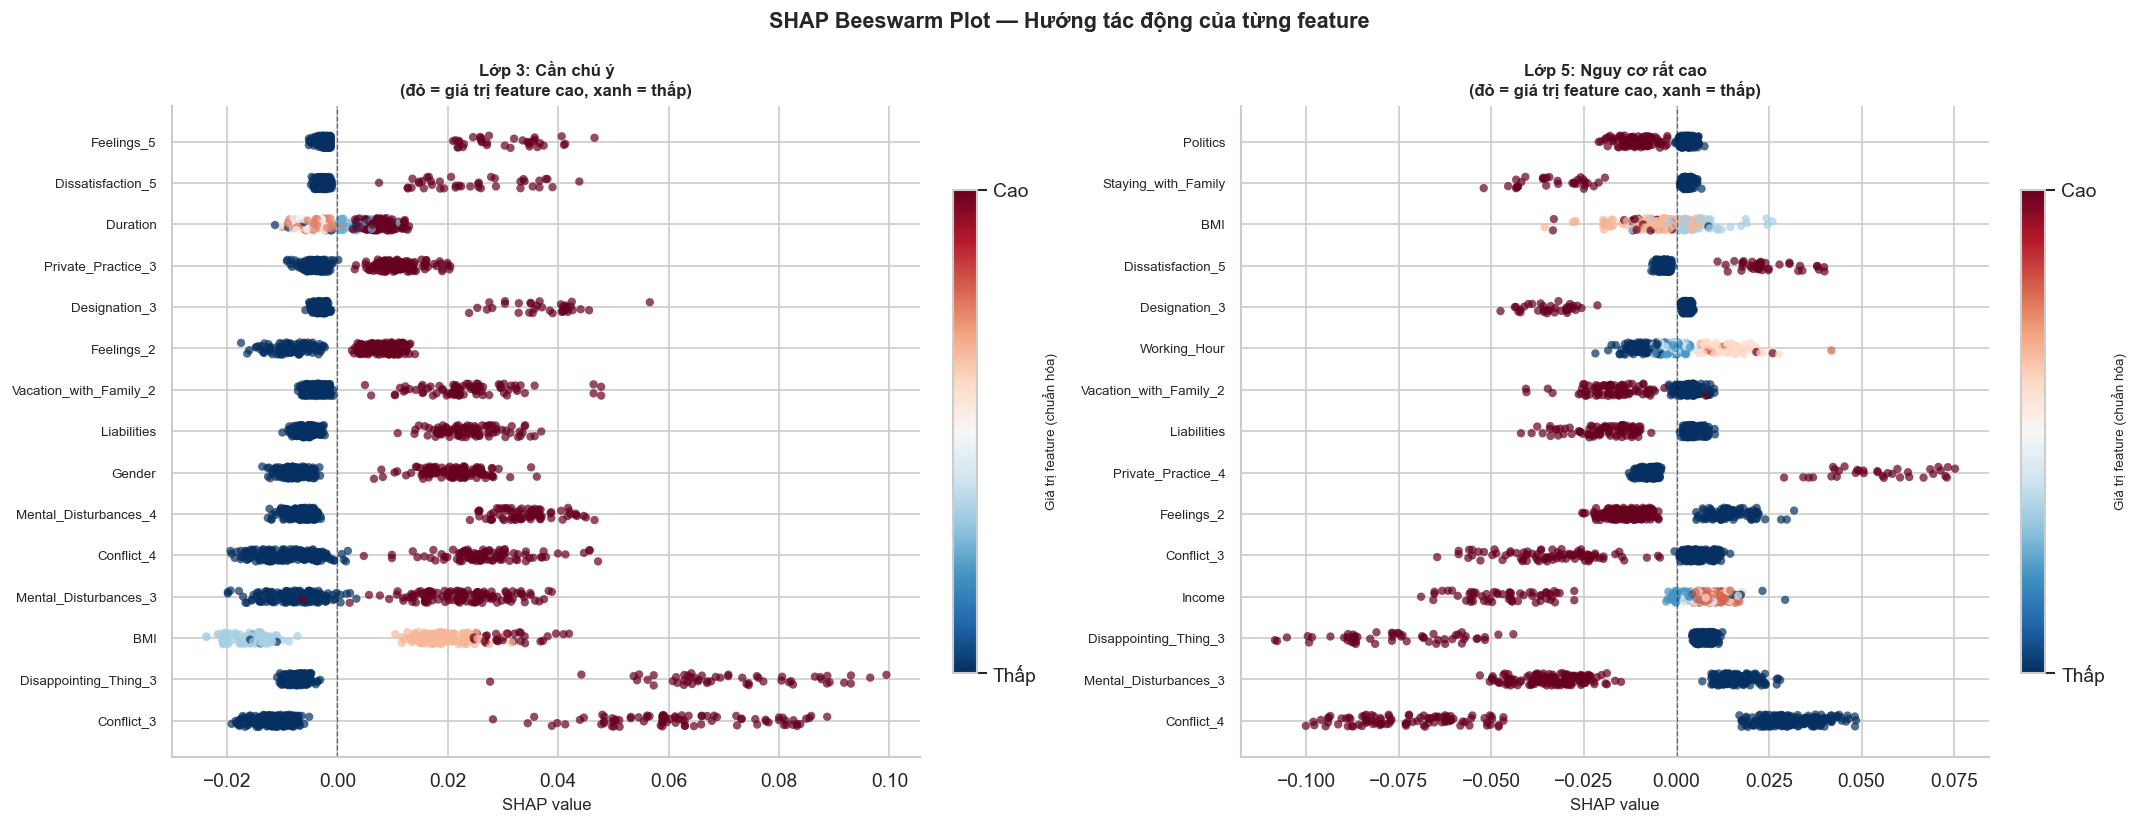

In [20]:
# Vẽ beeswarm cho 2 lớp quan trọng nhất: lớp chiếm đa số và lớp nguy cơ cao nhất
target_classes_plot = []
counts_test = pd.Series(y_test).value_counts().sort_index()
# Lấy lớp nhiều mẫu nhất và lớp có code cao nhất trong test
dominant_cls = counts_test.idxmax()
highest_cls  = classes[-1]
for c in [dominant_cls, highest_cls]:
    if c in classes and c not in target_classes_plot:
        target_classes_plot.append(c)
if len(target_classes_plot) == 1:
    for c in classes:
        if c not in target_classes_plot:
            target_classes_plot.append(c)
            break

fig, axes = plt.subplots(1, len(target_classes_plot),
                         figsize=(9 * len(target_classes_plot), 7))
if len(target_classes_plot) == 1:
    axes = [axes]

for ax, cls in zip(axes, target_classes_plot):
    cls_idx  = classes.index(cls)
    if isinstance(shap_values, list):
        sv = shap_values[cls_idx]
    else:
        # Lấy toàn bộ sample và feature, chỉ chọn class tương ứng ở trục số 3
        sv = shap_values[:, :, cls_idx]
    means    = np.abs(sv).mean(axis=0)
    top_idx  = np.argsort(means)[::-1][:15]

    # Lấy dữ liệu SHAP và Feature cho top features
    sv_top   = sv[:, top_idx]
    feat_top = [kept_cols[j] for j in top_idx]
   
    # QUAN TRỌNG: Đảm bảo lấy đúng các cột từ X_test dựa trên kept_cols
    # X_test_filtered giúp đảm bảo số lượng mẫu khớp hoàn toàn với sv_top
    X_test_plot = X_test[kept_cols].iloc[:, top_idx].values

    # Chuẩn hóa màu theo giá trị feature
    for feat_i in range(sv_top.shape[1]):
        x_vals    = sv_top[:, feat_i]
        c_vals    = X_test_plot[:, feat_i] # Lấy từ mảng đã khớp kích thước
        
        y_vals    = np.full(len(x_vals), feat_i) # Tạo y_vals dựa trên len của x_vals thực tế

        # Tính toán màu sắc
        c_min, c_max = c_vals.min(), c_vals.max()
        if c_max - c_min > 0:
            c_norm = (c_vals - c_min) / (c_max - c_min)
        else:
            c_norm = np.zeros_like(c_vals)

        colors_pt = plt.cm.RdBu_r(c_norm)

        # Vẽ scatter với jitter (độ nhiễu) để tránh các điểm đè lên nhau
        ax.scatter(x_vals, y_vals + np.random.uniform(-0.15, 0.15, len(x_vals)),
                   c=colors_pt, alpha=0.7, s=25, linewidths=0)

    ax.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_yticks(range(15))
    ax.set_yticklabels(feat_top, fontsize=8)
    ax.set_xlabel('SHAP value', fontsize=10)
    ax.set_title(
        f'Lớp {cls}: {BURNOUT_LABEL.get(cls,str(cls))}\n'
        f'(đỏ = giá trị feature cao, xanh = thấp)',
        fontweight='bold', fontsize=10
    )

    # Colorbar
    sm = plt.cm.ScalarMappable(cmap='RdBu_r',
                               norm=plt.Normalize(vmin=0, vmax=1))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.04)
    cbar.set_label('Giá trị feature (chuẩn hóa)', fontsize=8)
    cbar.set_ticks([0, 1])
    cbar.set_ticklabels(['Thấp', 'Cao'])

plt.suptitle('SHAP Beeswarm Plot — Hướng tác động của từng feature',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/24_shap_beeswarm.png', bbox_inches='tight')
plt.show()

### Task 8:  SHAP Waterfall Plot: Giải thích từng dự đoán cụ thể

**Waterfall Plot** trả lời câu hỏi: *"Tại sao model dự đoán người này bị burnout ở mức X?"*

Vẽ cho 3 mẫu trong test set:
1. Một mẫu dự đoán **đúng** với xác suất cao nhất
2. Một mẫu dự đoán **sai** để phân tích lý do

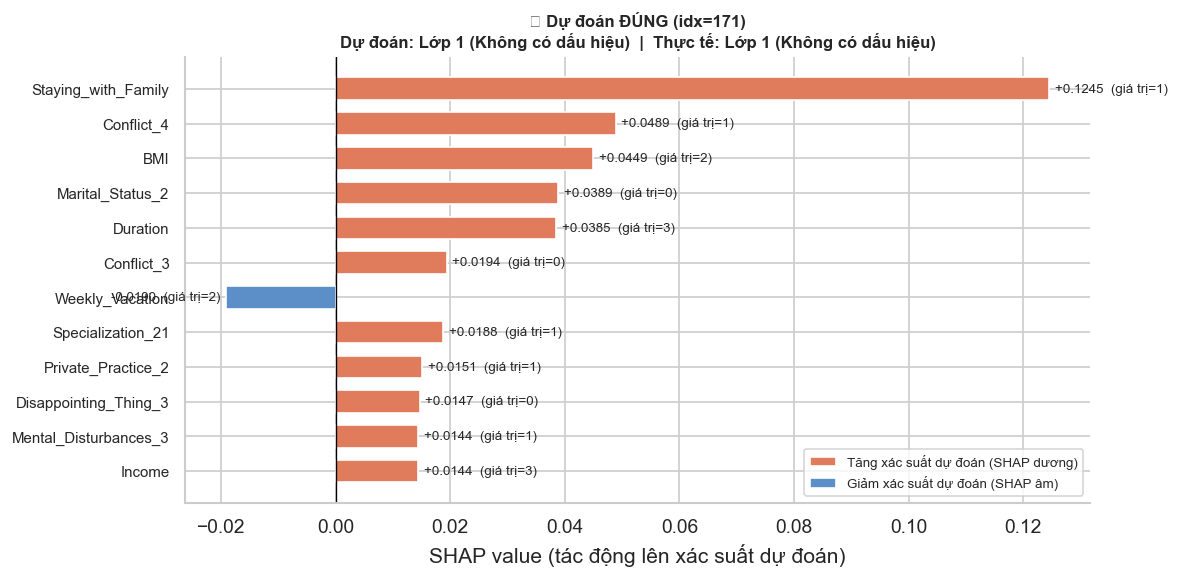

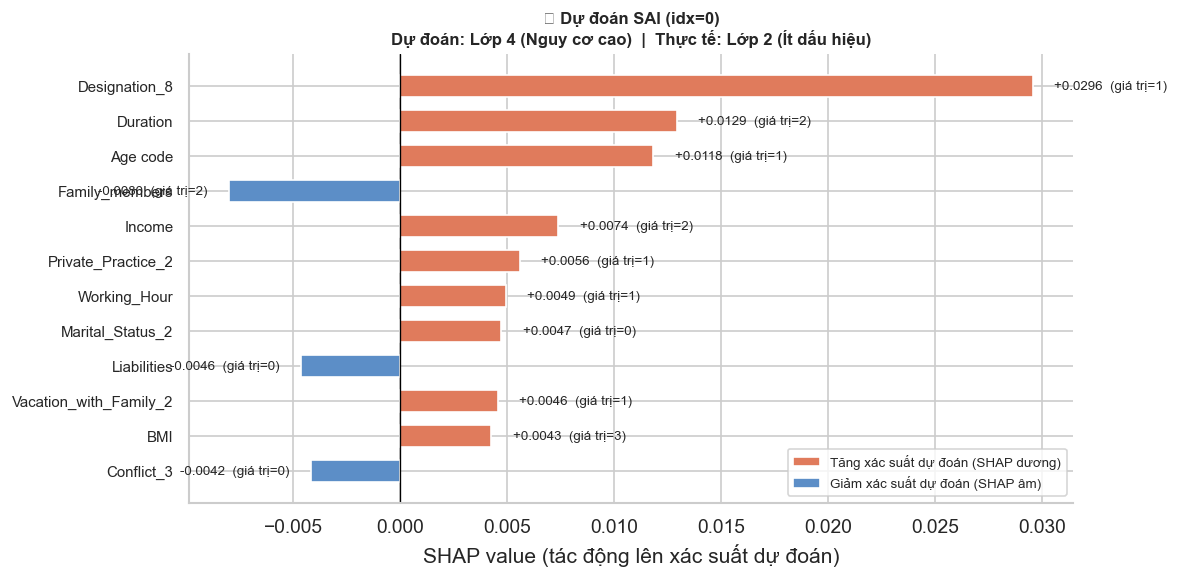

In [22]:
y_pred_arr = np.array(y_pred)
y_test_arr = np.array(y_test)

# Tìm mẫu dự đoán đúng với confidence cao nhất
correct_mask   = (y_pred_arr == y_test_arr)
correct_idx    = np.where(correct_mask)[0]
wrong_idx      = np.where(~correct_mask)[0]

samples_to_explain = []
labels_explain     = []

if len(correct_idx) > 0:
    # Mẫu đúng có xác suất cao nhất
    probs_correct = np.max(y_prob[correct_idx], axis=1)
    best_correct  = correct_idx[np.argmax(probs_correct)]
    samples_to_explain.append(best_correct)
    labels_explain.append(f'✅ Dự đoán ĐÚNG (idx={best_correct})')

if len(wrong_idx) > 0:
    # Mẫu sai đầu tiên
    samples_to_explain.append(wrong_idx[0])
    labels_explain.append(f'❌ Dự đoán SAI (idx={wrong_idx[0]})')

for sample_idx, label in zip(samples_to_explain, labels_explain):
    pred_class  = y_pred_arr[sample_idx]
    true_class  = y_test_arr[sample_idx]
    cls_idx     = classes.index(pred_class)

    if isinstance(shap_values, list):
        sv_sample = shap_values[cls_idx][sample_idx]
    else:
        # Lấy một mẫu cụ thể của toàn bộ feature tương ứng với một class cụ thể
        sv_sample = shap_values[sample_idx, :, cls_idx]
        
    base_val    = explainer.expected_value[cls_idx] if hasattr(explainer.expected_value, '__len__') \
                  else explainer.expected_value

    # Sắp xếp features theo |SHAP|
    sorted_idx  = np.argsort(np.abs(sv_sample))[::-1][:12]
    feat_names  = [kept_cols[j] for j in sorted_idx]
    shap_vals   = sv_sample[sorted_idx]
    feat_vals   = X_test.iloc[sample_idx, sorted_idx].values

    fig, ax = plt.subplots(figsize=(10, 5))
    colors_w = ['#E07B5C' if v > 0 else '#5C8EC7' for v in shap_vals[::-1]]
    y_pos    = range(len(shap_vals))
    bars     = ax.barh(list(y_pos), shap_vals[::-1],
                       color=colors_w, edgecolor='white', height=0.65)
    for j, (bar, val, fval) in enumerate(zip(bars, shap_vals[::-1], feat_vals[::-1])):
        offset = 0.001 if val >= 0 else -0.001
        ha     = 'left' if val >= 0 else 'right'
        ax.text(val + offset, j,
                f'{val:+.4f}  (giá trị={fval})',
                va='center', ha=ha, fontsize=8)
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(feat_names[::-1], fontsize=9)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('SHAP value (tác động lên xác suất dự đoán)')
    ax.set_title(
        f'{label}\n'
        f'Dự đoán: Lớp {pred_class} ({BURNOUT_LABEL.get(pred_class,"")})'  
        f'  |  Thực tế: Lớp {true_class} ({BURNOUT_LABEL.get(true_class,"")})',
        fontweight='bold', fontsize=10
    )
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#E07B5C', label='Tăng xác suất dự đoán (SHAP dương)'),
        Patch(facecolor='#5C8EC7', label='Giảm xác suất dự đoán (SHAP âm)'),
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=8)
    plt.tight_layout()
    fname = f'correct' if '✅' in label else 'wrong'
    plt.savefig(f'{FIGURES_DIR}/25_shap_waterfall_{fname}.png', bbox_inches='tight')
    plt.show()

### Task 9: SHAP Dependence Plot: Tương tác giữa features

- **Dependence Plot** cho top 2 feature quan trọng nhất — xem giá trị feature thay đổi thì SHAP value thay đổi như thế nào.

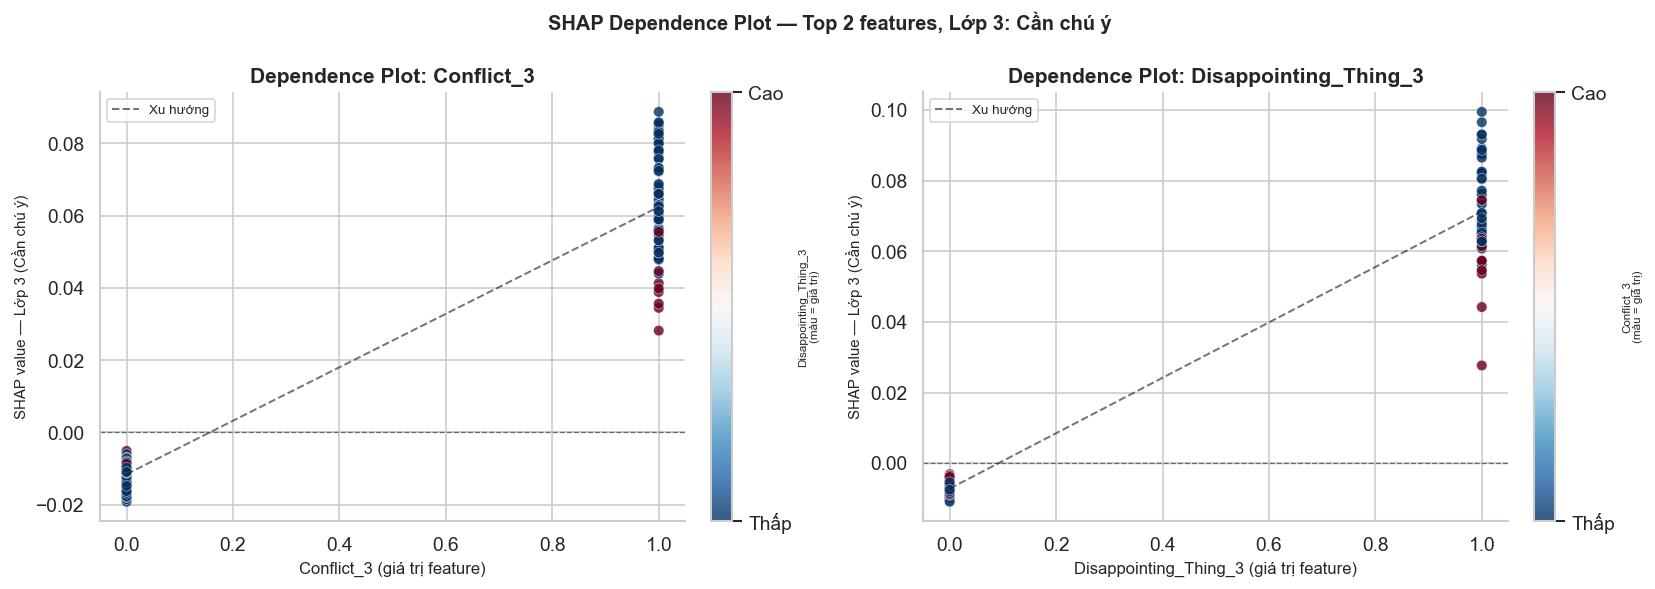

In [24]:
# Lấy lớp có nhiều mẫu nhất để phân tích dependence
main_cls     = counts_test.idxmax()
main_cls_idx = classes.index(main_cls)

if isinstance(shap_values, list):
        sv_main = shap_values[main_cls_idx]
else:
        # Lấy đầy đủ không gian tham số phân bố mẫu và feature
        sv_main = shap_values[:, :, main_cls_idx]


means_main   = np.abs(sv_main).mean(axis=0)
top2_idx     = np.argsort(means_main)[::-1][:2]
top2_feats   = [kept_cols[j] for j in top2_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, feat_name, feat_idx in zip(axes, top2_feats, top2_idx):
    x_vals    = X_test[feat_name].values
    shap_v    = sv_main[:, feat_idx]

    # Màu theo feature quan trọng thứ 2 (interaction)
    other_idx = top2_idx[1] if feat_idx == top2_idx[0] else top2_idx[0]
    color_v   = X_test.iloc[:, other_idx].values
    c_norm    = (color_v - color_v.min()) / (color_v.max() - color_v.min() + 1e-9)

    sc = ax.scatter(x_vals, shap_v, c=c_norm, cmap='RdBu_r',
                    alpha=0.8, s=40, edgecolors='white', linewidths=0.3)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

    # Trendline
    if len(x_vals) > 2:
        z   = np.polyfit(x_vals, shap_v, 1)
        p   = np.poly1d(z)
        x_s = np.linspace(x_vals.min(), x_vals.max(), 100)
        ax.plot(x_s, p(x_s), 'k--', linewidth=1.2, alpha=0.6, label='Xu hướng')
        ax.legend(fontsize=8)

    cbar = fig.colorbar(sc, ax=ax, fraction=0.04, pad=0.04)
    other_name = kept_cols[other_idx]
    cbar.set_label(f'{other_name}\n(màu = giá trị)', fontsize=7)
    cbar.set_ticks([0, 1])
    cbar.set_ticklabels(['Thấp', 'Cao'])

    ax.set_xlabel(f'{feat_name} (giá trị feature)', fontsize=10)
    ax.set_ylabel(f'SHAP value — Lớp {main_cls} ({BURNOUT_LABEL.get(main_cls,"")})',
                  fontsize=9)
    ax.set_title(f'Dependence Plot: {feat_name}', fontweight='bold')

plt.suptitle(f'SHAP Dependence Plot — Top 2 features, Lớp {main_cls}: {BURNOUT_LABEL.get(main_cls,"")}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/26_shap_dependence.png', bbox_inches='tight')
plt.show()

### Task 10: So sánh Feature Importance vs SHAP Importance
- Gini Feature Importance (từ notebook 03) vs SHAP Importance — hai phương pháp khác nhau, thứ hạng có thể khác nhau.

📊 So sánh xếp hạng Feature Importance (Gini) vs SHAP Importance:


,Feature,Gini Importance,Rank (Gini),SHAP Importance,Rank (SHAP),Δ Rank
0,Conflict_4,0.0730,1,0.01935,1,0
1,Income,0.0645,2,0.00873,6,-4
2,Duration,0.0576,3,0.00556,13,-10
3,Mental_Disturbances_3,0.0565,4,0.01880,2,2
4,Conflict_3,0.0516,5,0.01694,3,2
5,Disappointing_Thing_3,0.0473,6,0.01604,4,2
6,BMI,0.0419,7,0.01125,5,2
7,Working_Hour,0.0414,8,0.00410,20,-12
8,Staying_with_Family,0.0351,9,0.00551,14,-5
9,Age code,0.0324,10,0.00294,25,-15


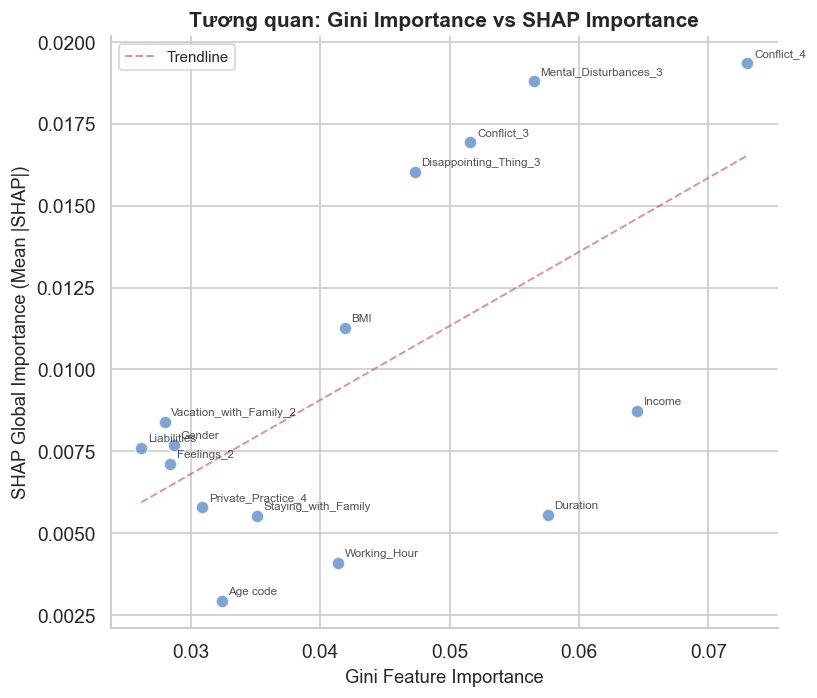

In [25]:
fi_df = pd.read_csv(f'{MODELS_DIR}/feature_importance.csv')
fi_df = fi_df.set_index('feature')['importance']

# Chỉ giữ features có trong cả hai
common = [f for f in shap_mean_series.index if f in fi_df.index]
fi_common   = fi_df[common].sort_values(ascending=False)
shap_common = shap_mean_series[common]

top_k = min(15, len(common))
top_feats_fi = fi_common.head(top_k).index.tolist()

# Ranking
fi_rank   = {f: i+1 for i, f in enumerate(fi_common.index)}
shap_rank = {f: i+1 for i, f in enumerate(shap_common.sort_values(ascending=False).index)}

compare_df = pd.DataFrame({
    'Feature'        : top_feats_fi,
    'Gini Importance': fi_common[top_feats_fi].round(4).values,
    'Rank (Gini)'    : [fi_rank[f] for f in top_feats_fi],
    'SHAP Importance': shap_common[top_feats_fi].round(5).values,
    'Rank (SHAP)'    : [shap_rank[f] for f in top_feats_fi],
})
compare_df['Δ Rank'] = compare_df['Rank (Gini)'] - compare_df['Rank (SHAP)']

print('📊 So sánh xếp hạng Feature Importance (Gini) vs SHAP Importance:')
display(compare_df)

# ── Scatter plot tương quan hai phương pháp ───────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(compare_df['Gini Importance'], compare_df['SHAP Importance'],
           color='#5C8EC7', s=60, alpha=0.8, edgecolors='white')
for _, row in compare_df.iterrows():
    ax.annotate(row['Feature'],
                (row['Gini Importance'], row['SHAP Importance']),
                fontsize=7, xytext=(4, 4), textcoords='offset points', alpha=0.8)
ax.set_xlabel('Gini Feature Importance', fontsize=11)
ax.set_ylabel('SHAP Global Importance (Mean |SHAP|)', fontsize=11)
ax.set_title('Tương quan: Gini Importance vs SHAP Importance', fontweight='bold')

# Trendline
if len(compare_df) > 2:
    z = np.polyfit(compare_df['Gini Importance'], compare_df['SHAP Importance'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(compare_df['Gini Importance'].min(),
                         compare_df['Gini Importance'].max(), 100)
    ax.plot(x_line, p(x_line), 'r--', linewidth=1.2, alpha=0.6, label='Trendline')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/27_fi_vs_shap.png', bbox_inches='tight')
plt.show()

### Task 11: Tổng kết nhận xét
- Tự động tổng hợp các con số và nhận xét chính

In [ ]:
top3_shap = shap_mean_series.head(3)
top3_fi   = fi_df.sort_values(ascending=False).head(3)

print('=' * 68)
print('      TỔNG KẾT ĐÁNH GIÁ & DIỄN GIẢI MÔ HÌNH')
print('=' * 68)
print(f"""
━━━ KẾT QUẢ MÔ HÌNH (Test Set) ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Accuracy          : {acc:.4f}  ({acc*100:.2f}%)
   Precision         : {prec:.4f}  (weighted)
   Recall            : {rec:.4f}  (weighted)
   F1-score          : {f1_w:.4f}  (weighted)
   F1-score          : {f1_m:.4f}  (macro)
   ROC-AUC           : {roc_auc_macro:.4f}  (macro OvR)

━━━ PHÂN TÍCH FEATURE IMPORTANCE (GINI) ━━━━━━━━━━━━━━━━━━━━━━
   Top 3 yếu tố quan trọng nhất theo Gini Impurity:
   1. {top3_fi.index[0]:35s}: {top3_fi.iloc[0]:.4f}
   2. {top3_fi.index[1]:35s}: {top3_fi.iloc[1]:.4f}
   3. {top3_fi.index[2]:35s}: {top3_fi.iloc[2]:.4f}

━━━ PHÂN TÍCH SHAP VALUES ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Top 3 yếu tố theo SHAP global importance:
   1. {top3_shap.index[0]:35s}: {top3_shap.iloc[0]:.5f}
   2. {top3_shap.index[1]:35s}: {top3_shap.iloc[1]:.5f}
   3. {top3_shap.index[2]:35s}: {top3_shap.iloc[2]:.5f}

━━━ BIỂU ĐỒ ĐÃ LƯU (reports/figures/) ━━━━━━━━━━━━━━━━━━━━━━━
   20_metrics_dashboard.png     — Dashboard metrics tổng hợp
   21_roc_curve.png             — ROC Curve multi-class OvR
   22_shap_global_importance.png — SHAP global importance bar
   23_shap_per_class.png        — SHAP importance theo lớp
   24_shap_beeswarm.png         — SHAP beeswarm (hướng tác động)
   25_shap_waterfall_*.png      — Giải thích từng dự đoán
   26_shap_dependence.png       — SHAP dependence plot
   27_fi_vs_shap.png            — So sánh Gini vs SHAP

━━━ GỢI Ý CHO CHƯƠNG 5 (Thảo luận) ━━━━━━━━━━━━━━━━━━━━━━━━━━
   • Đề cập feature quan trọng nhất (theo cả Gini và SHAP)
   • Giải thích ý nghĩa lâm sàng của từng yếu tố
   • Nêu hạn chế: dataset chỉ có {config['test_size'] + config['train_size_before_smote']:,} mẫu,
     overfit gap = {config['gap_cv_test']:.4f}
   • Hướng nghiên cứu tiếp: thêm dữ liệu, thử XGBoost, deep learning
""")

      TỔNG KẾT ĐÁNH GIÁ & DIỄN GIẢI MÔ HÌNH

━━━ KẾT QUẢ MÔ HÌNH (Test Set) ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Accuracy          : 0.3798  (37.98%)
   Precision         : 0.3799  (weighted)
   Recall            : 0.3798  (weighted)
   F1-score          : 0.3744  (weighted)
   F1-score          : 0.2325  (macro)
   ROC-AUC           : 0.5905  (macro OvR)

━━━ PHÂN TÍCH FEATURE IMPORTANCE (GINI) ━━━━━━━━━━━━━━━━━━━━━━
   Top 3 yếu tố quan trọng nhất theo Gini Impurity:
   1. Conflict_4                         : 0.0730
   2. Income                             : 0.0645
   3. Duration                           : 0.0576

━━━ PHÂN TÍCH SHAP VALUES ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Top 3 yếu tố theo SHAP global importance:
   1. Conflict_4                         : 0.01935
   2. Mental_Disturbances_3              : 0.01880
   3. Conflict_3                         : 0.01694

━━━ BIỂU ĐỒ ĐÃ LƯU (reports/figures/) ━━━━━━━━━━━━━━━━━━━━━━━
   20_metrics_dashboard.png     — Dashboard metrics tổ